# AI-Based Personality Prediction (MBTI)

## Model Training and Evaluation

This notebook assumes that:
- You have already run the EDA & preprocessing notebook.
- A cleaned dataset (e.g., `clean_mbti_dataset.csv`) exists.
- Text has already been preprocessed into a column such as `normalized_posts`.

We will:
1. Load the cleaned data and TF-IDF features.
2. Train multiple models for 16-class MBTI prediction.
3. Evaluate and compare models.
4. Train separate binary models for each MBTI trait.
5. Do simple explainability for Logistic Regression.
6. Save the best model for later deployment.

In [12]:
# Imports

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

plt.style.use('seaborn-v0_8')

## Load Cleaned Dataset and Build TF-IDF Features

In [13]:
# Load the cleaned MBTI dataset (created in the EDA & preprocessing notebook)

df = pd.read_csv("clean_mbti_dataset.csv")
print(df.head())
print("\nColumns:", df.columns.tolist())

# Choose text column and label column
TEXT_COL = "normalized_posts"   # change if your column name is different
LABEL_COL = "type"              # change if your MBTI label column has another name

X_text = df[TEXT_COL].fillna("").astype(str)
y = df[LABEL_COL]

# TF-IDF vectorization

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,      # keep it reasonable for speed
    ngram_range=(1, 2),     # unigrams + bigrams
    stop_words=None         # text already cleaned in previous notebook
)

X = tfidf_vectorizer.fit_transform(X_text)

print("\nTF-IDF matrix shape:", X.shape)

   type                                              posts  \
0  INFJ  'http://www.youtube.com/watch?v=qsXHcwe3krw|||...   
1  ENTP  'I'm finding the lack of me in these posts ver...   
2  INTP  'Good one  _____   https://www.youtube.com/wat...   
3  INTJ  'Dear INTP,   I enjoyed our conversation the o...   
4  ENTJ  'You're fired.|||That's another silly misconce...   

                                       cleaned_posts  \
0  and intj moments sportscenter not top ten play...   
1  i m finding the lack of me in these posts very...   
2  good one course to which i say i know that s m...   
3  dear intp i enjoyed our conversation the other...   
4  you re fired that s another silly misconceptio...   

                                    normalized_posts  norm_char_count  \
0  intj moment sportscenter top ten play prank li...             1997   
1  finding lack post alarming sex boring position...             3556   
2  good one course say know blessing curse absolu...             2855  

## Train-Test Split

In [14]:
# Create train-test split (80-20) with stratification on MBTI labels

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (6940, 5000)
Test shape: (1735, 5000)


## Model Training (16-Class Classification)

In [15]:
# Train three different models on the 16-class MBTI task

models = {}

# 1. Logistic Regression (multiclass, one-vs-rest)
log_reg = LogisticRegression(
    max_iter=200,
    n_jobs=-1,
    multi_class="ovr"
)
log_reg.fit(X_train, y_train)
models["Logistic Regression"] = log_reg

# 2. Multinomial Naive Bayes
nb_clf = MultinomialNB()
nb_clf.fit(X_train, y_train)
models["Multinomial NB"] = nb_clf

# 3. Random Forest Classifier
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)
models["Random Forest"] = rf_clf

print("Models trained:")
for name in models.keys():
    print("-", name)

c:\Users\SIDDHI SUSHIR\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Models trained:
- Logistic Regression
- Multinomial NB
- Random Forest


## Evaluation (16-Class Classification)

Model: Logistic Regression
Accuracy: 0.6467



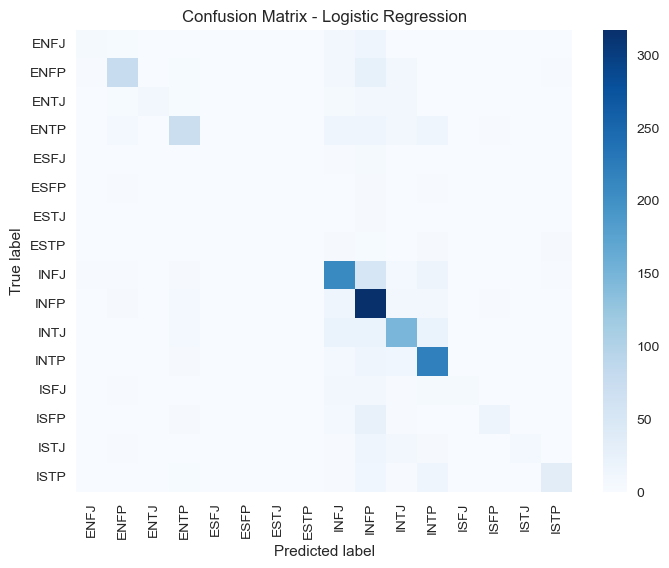

Classification Report:
              precision    recall  f1-score   support

        ENFJ       0.56      0.13      0.21        38
        ENFP       0.75      0.58      0.65       135
        ENTJ       0.62      0.22      0.32        46
        ENTP       0.65      0.53      0.59       137
        ESFJ       0.00      0.00      0.00         9
        ESFP       0.00      0.00      0.00        10
        ESTJ       0.00      0.00      0.00         8
        ESTP       1.00      0.06      0.11        18
        INFJ       0.65      0.71      0.68       294
        INFP       0.58      0.87      0.70       366
        INTJ       0.64      0.67      0.66       218
        INTP       0.70      0.84      0.76       261
        ISFJ       0.71      0.15      0.25        33
        ISFP       0.81      0.31      0.45        54
        ISTJ       0.78      0.17      0.28        41
        ISTP       0.71      0.51      0.59        67

    accuracy                           0.65      1735
   

c:\Users\SIDDHI SUSHIR\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SIDDHI SUSHIR\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SIDDHI SUSHIR\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


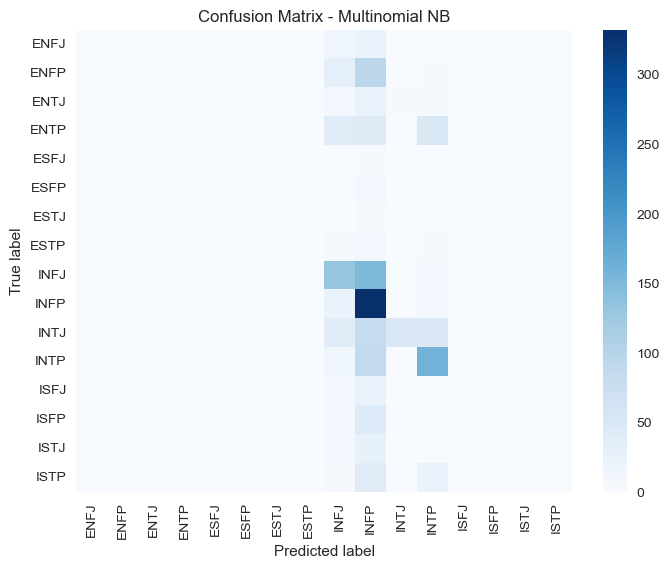

Classification Report:
              precision    recall  f1-score   support

        ENFJ       0.00      0.00      0.00        38
        ENFP       1.00      0.01      0.01       135
        ENTJ       0.00      0.00      0.00        46
        ENTP       0.33      0.01      0.01       137
        ESFJ       0.00      0.00      0.00         9
        ESFP       0.00      0.00      0.00        10
        ESTJ       0.00      0.00      0.00         8
        ESTP       0.00      0.00      0.00        18
        INFJ       0.38      0.45      0.41       294
        INFP       0.33      0.91      0.49       366
        INTJ       0.69      0.22      0.33       218
        INTP       0.49      0.61      0.55       261
        ISFJ       0.00      0.00      0.00        33
        ISFP       0.00      0.00      0.00        54
        ISTJ       0.00      0.00      0.00        41
        ISTP       0.00      0.00      0.00        67

    accuracy                           0.39      1735
   

c:\Users\SIDDHI SUSHIR\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SIDDHI SUSHIR\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SIDDHI SUSHIR\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.5798



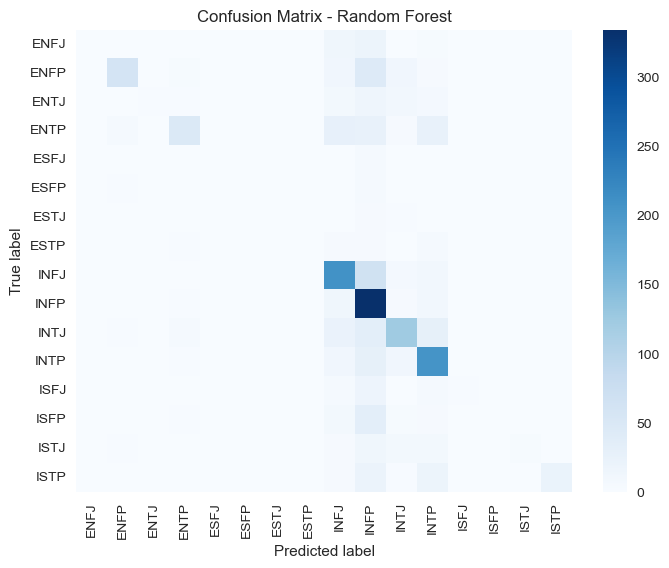

Classification Report:
              precision    recall  f1-score   support

        ENFJ       1.00      0.03      0.05        38
        ENFP       0.80      0.44      0.56       135
        ENTJ       1.00      0.04      0.08        46
        ENTP       0.68      0.34      0.46       137
        ESFJ       0.00      0.00      0.00         9
        ESFP       0.00      0.00      0.00        10
        ESTJ       0.00      0.00      0.00         8
        ESTP       0.00      0.00      0.00        18
        INFJ       0.60      0.71      0.65       294
        INFP       0.50      0.91      0.64       366
        INTJ       0.64      0.56      0.60       218
        INTP       0.60      0.79      0.68       261
        ISFJ       0.67      0.06      0.11        33
        ISFP       1.00      0.02      0.04        54
        ISTJ       0.75      0.07      0.13        41
        ISTP       0.81      0.31      0.45        67

    accuracy                           0.58      1735
   

c:\Users\SIDDHI SUSHIR\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SIDDHI SUSHIR\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SIDDHI SUSHIR\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
# Helper function to evaluate a model on the test set

def evaluate_model(name, model, X_test, y_test):
    print("=" * 80)
    print(f"Model: {name}")
    print("=" * 80)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}\n")
    
    # Confusion matrix
    labels_sorted = sorted(y_test.unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=False,
        cmap="Blues",
        xticklabels=labels_sorted,
        yticklabels=labels_sorted
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.show()
    
    # Classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    return acc

# Evaluate each model and store accuracy
model_accuracies = {}

for model_name, model in models.items():
    acc = evaluate_model(model_name, model, X_test, y_test)
    model_accuracies[model_name] = acc

## Model Comparison

Model accuracy comparison (16-class task):
                 Model  Accuracy
0  Logistic Regression  0.646686
1        Random Forest  0.579827
2       Multinomial NB  0.387896


C:\Users\SIDDHI SUSHIR\AppData\Local\Temp\ipykernel_68156\1076052547.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x="Model", y="Accuracy", palette="viridis")


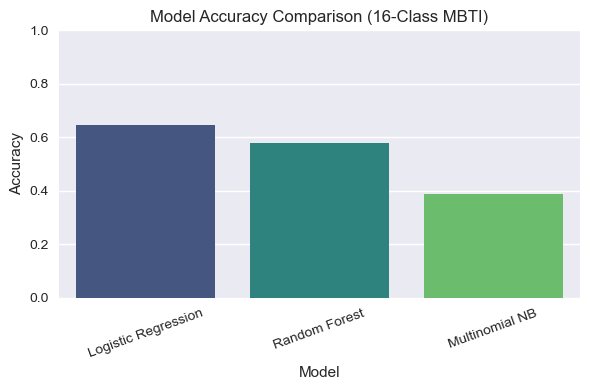


Best performing model (16-class): Logistic Regression


In [17]:
# Create a simple comparison table and bar chart of accuracies

comparison_df = pd.DataFrame(
    list(model_accuracies.items()),
    columns=["Model", "Accuracy"]
).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print("Model accuracy comparison (16-class task):")
print(comparison_df)

plt.figure(figsize=(6, 4))
sns.barplot(data=comparison_df, x="Model", y="Accuracy", palette="viridis")
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison (16-Class MBTI)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Identify best model by accuracy
best_model_name = comparison_df.loc[0, "Model"]
best_model = models[best_model_name]

print(f"\nBest performing model (16-class): {best_model_name}")

## Binary Classification for Each MBTI Trait (I/E, N/S, T/F, J/P)

In [18]:
# For binary trait classification we assume y contains full MBTI types as 4-character strings
# Example: 'INTJ', 'ESFP', etc.

traits = {
    "I_vs_E": (0, "I", "E"),
    "N_vs_S": (1, "N", "S"),
    "T_vs_F": (2, "T", "F"),
    "J_vs_P": (3, "J", "P"),
}

binary_results = {}

for name, (idx, pos_letter, neg_letter) in traits.items():
    print("=" * 80)
    print(f"Binary trait: {name} ({pos_letter} vs {neg_letter})")
    print("=" * 80)
    
    # Create binary labels from the MBTI string
    y_trait = y.str[idx].map(lambda c: 1 if c == pos_letter else 0)
    
    X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
        X,
        y_trait,
        test_size=0.2,
        random_state=42,
        stratify=y_trait
    )
    
    # Simple Logistic Regression for each binary trait
    clf = LogisticRegression(max_iter=200, n_jobs=-1)
    clf.fit(X_train_b, y_train_b)
    
    y_pred_b = clf.predict(X_test_b)
    acc_b = accuracy_score(y_test_b, y_pred_b)
    
    print(f"Accuracy: {acc_b:.4f}")
    print("Classification Report:")
    print(classification_report(y_test_b, y_pred_b, target_names=[neg_letter, pos_letter]))
    
    binary_results[name] = {
        "model": clf,
        "accuracy": acc_b
    }

print("\nBinary trait accuracies:")
for trait_name, info in binary_results.items():
    print(f"- {trait_name}: {info['accuracy']:.4f}")

Binary trait: I_vs_E (I vs E)
Accuracy: 0.8461
Classification Report:
              precision    recall  f1-score   support

           E       0.86      0.40      0.55       400
           I       0.84      0.98      0.91      1335

    accuracy                           0.85      1735
   macro avg       0.85      0.69      0.73      1735
weighted avg       0.85      0.85      0.82      1735

Binary trait: N_vs_S (N vs S)
Accuracy: 0.8859
Classification Report:
              precision    recall  f1-score   support

           S       0.77      0.24      0.37       239
           N       0.89      0.99      0.94      1496

    accuracy                           0.89      1735
   macro avg       0.83      0.62      0.65      1735
weighted avg       0.87      0.89      0.86      1735

Binary trait: T_vs_F (T vs F)
Accuracy: 0.8490
Classification Report:
              precision    recall  f1-score   support

           F       0.86      0.87      0.86       939
           T       0.84    

## Explainability: Top Words for Logistic Regression

In [19]:
# For interpretability, we extract top words for a couple of MBTI classes

feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

# We will use the Logistic Regression 16-class model for feature importance
log_reg_model = models.get("Logistic Regression", None)
if log_reg_model is None:
    raise ValueError("Logistic Regression model not found in `models` dictionary.")

# Each row in coef_ corresponds to a class; columns correspond to features (words)
class_labels = log_reg_model.classes_
coefs = log_reg_model.coef_

def show_top_words_for_class(class_label, top_n=10):
    """Print top positive-weight words for a given MBTI class."""
    # Find index of class
    class_idx = list(class_labels).index(class_label)
    class_coefs = coefs[class_idx]
    
    # Get indices of top coefficients
    top_indices = np.argsort(class_coefs)[-top_n:][::-1]
    top_words = feature_names[top_indices]
    top_weights = class_coefs[top_indices]
    
    print(f"Top {top_n} words for class '{class_label}':")
    for w, wgt in zip(top_words, top_weights):
        print(f"{w:20s}  weight = {wgt:.4f}")
    print("\n")

# Example: show top words for two personality types
show_top_words_for_class("INTJ", top_n=10)
show_top_words_for_class("ESFP", top_n=10)

Top 10 words for class 'INTJ':
intj                  weight = 13.7206
intjs                 weight = 7.3149
plan                  weight = 2.0410
type intj             weight = 1.7357
ni                    weight = 1.5427
know intj             weight = 1.3494
research              weight = 1.2659
eat                   weight = 1.2350
would                 weight = 1.1591
stupid                weight = 1.0899


Top 10 words for class 'ESFP':
esfp                  weight = 3.7087
estp                  weight = 0.8602
esfps                 weight = 0.6613
kitteh                weight = 0.6462
tmlt                  weight = 0.6293
using tapatalk        weight = 0.5952
tapatalk              weight = 0.5905
thanks                weight = 0.4931
laughing              weight = 0.4649
isfp                  weight = 0.4632




## Save Best Model

In [20]:
# Save the best-performing 16-class model to disk for later use (e.g., in a web app)

best_model_filename = f"best_mbti_model_{best_model_name.replace(' ', '_').lower()}.joblib"

joblib.dump(best_model, best_model_filename)
print(f"Best model saved to: {best_model_filename}")

# Also save the TF-IDF vectorizer for use at inference time
vectorizer_filename = "tfidf_vectorizer.joblib"
joblib.dump(tfidf_vectorizer, vectorizer_filename)
print(f"TF-IDF vectorizer saved to: {vectorizer_filename}")

Best model saved to: best_mbti_model_logistic_regression.joblib
TF-IDF vectorizer saved to: tfidf_vectorizer.joblib
